# K-Nearest Neighbors Classification

My goal here is to see how the choice of `k` changes a classifier, not just its final accuracy.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_breast_cancer, make_classification
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


## 1. Small classification example

I keep the class proportions similar in both splits and scale the features because KNN compares distances.


In [2]:
X_demo, y_demo = make_classification(
    n_samples=100,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=1.25,
    random_state=42,
)
# Stratification preserves the class ratio in both splits.
X_train, X_test, y_train, y_test = train_test_split(
    X_demo, y_demo, test_size=0.25, stratify=y_demo, random_state=42
)

demo_model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=3))
demo_model.fit(X_train, y_train)
print(f"Training accuracy: {demo_model.score(X_train, y_train):.3f}")
print(f"Test accuracy: {demo_model.score(X_test, y_test):.3f}")
print(f"First five test predictions: {demo_model.predict(X_test[:5])}")


Training accuracy: 1.000
Test accuracy: 1.000
First five test predictions: [1 1 1 0 1]


## 2. How `k` changes the boundary

A small `k` follows local details closely. A larger `k` produces a smoother boundary but can miss useful structure.


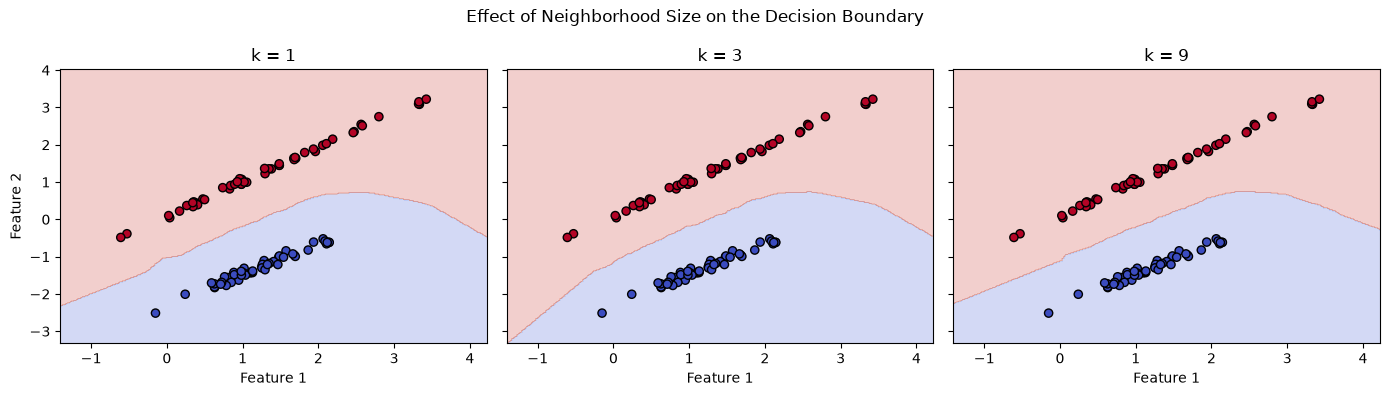

In [3]:
padding = 0.8
x0_min, x0_max = X_demo[:, 0].min() - padding, X_demo[:, 0].max() + padding
x1_min, x1_max = X_demo[:, 1].min() - padding, X_demo[:, 1].max() + padding
xx, yy = np.meshgrid(
    np.linspace(x0_min, x0_max, 300),
    np.linspace(x1_min, x1_max, 300),
)
grid = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True, sharey=True)
# These models use all demo points only to visualize their boundaries.
for neighbors, ax in zip([1, 3, 9], axes):
    model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=neighbors))
    model.fit(X_demo, y_demo)
    boundary = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, boundary, alpha=0.25, cmap="coolwarm")
    ax.scatter(X_demo[:, 0], X_demo[:, 1], c=y_demo, cmap="coolwarm", edgecolor="black", s=35)
    ax.set_title(f"k = {neighbors}")
    ax.set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")
fig.suptitle("Effect of Neighborhood Size on the Decision Boundary")
plt.tight_layout()
plt.show()


## 3. Breast-cancer data

I select `k` with cross-validation on the training set and use the test set once at the end. The high score is useful for this exercise, but it is not evidence that the model is ready for clinical use.


Best number of neighbors: 9
Best cross-validation accuracy: 0.967
Held-out test accuracy: 0.965


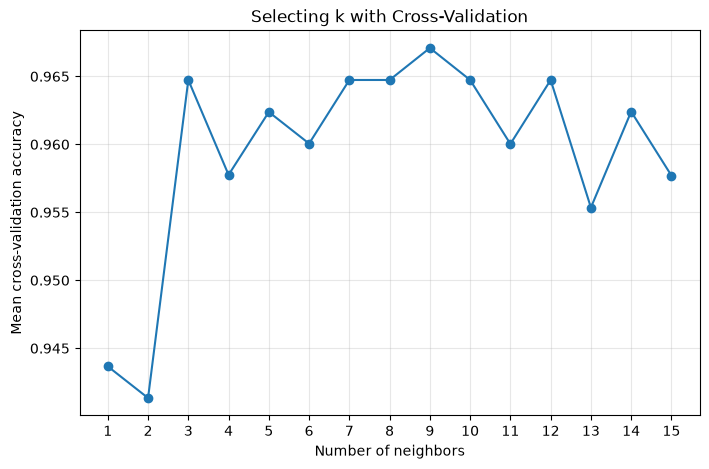

In [4]:
cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data,
    cancer.target,
    test_size=0.25,
    stratify=cancer.target,
    random_state=42,
)

pipeline = make_pipeline(StandardScaler(), KNeighborsClassifier())
# Tune on training folds; keep the test set for the final score.
search = GridSearchCV(
    pipeline,
    param_grid={"kneighborsclassifier__n_neighbors": list(range(1, 16))},
    cv=5,
    scoring="accuracy",
)
search.fit(X_train, y_train)

mean_cv_scores = search.cv_results_["mean_test_score"]
neighbor_values = search.param_grid["kneighborsclassifier__n_neighbors"]
print(f"Best number of neighbors: {search.best_params_['kneighborsclassifier__n_neighbors']}")
print(f"Best cross-validation accuracy: {search.best_score_:.3f}")
print(f"Held-out test accuracy: {search.score(X_test, y_test):.3f}")

plt.figure(figsize=(8, 5))
plt.plot(neighbor_values, mean_cv_scores, marker="o")
plt.xlabel("Number of neighbors")
plt.ylabel("Mean cross-validation accuracy")
plt.title("Selecting k with Cross-Validation")
plt.xticks(neighbor_values)
plt.grid(alpha=0.3)
plt.show()
